## CS5004 E-tivity 3

Name: Sean Noonan

StudentId: 2300159

# Task 1:
Windy grid learning


In [5]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import random

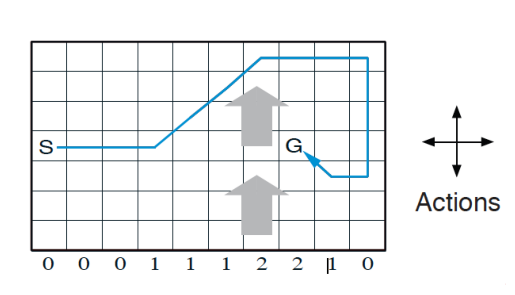

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "windy_gridworld.png"
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.axis("off")  # Hide axis labels
plt.show()


Person starts at S, moves at random until they reach G. There is a wind that deflects their movement given for each column by (0,0,0,1,1,1,2,2,1,0). Each move has a reward of -1.

We want to find an optimal policy from moving to start to goal

In [7]:
# Follow Q-learning algorithm

# Gridworld dimensions
# 7x10 gid
rows = 7
cols = 10
# We begin midway down the first column and want to finish
start = (3, 0)
goal = (3, 7)

# Wind strength per column
wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

# Actions: Up, Down, Left, Right
actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # Right, Left, Up, Down

In [8]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.5   # Learning rate
gamma = 1.0   # reward difference decay rate

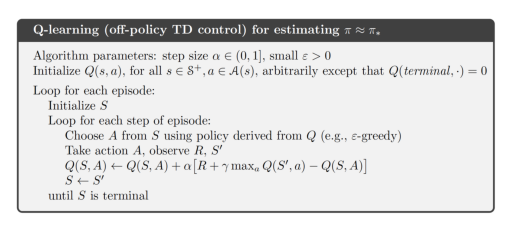

In [9]:
# Load the image
image_path1 = "Qlearning_algorithm.png"  # Replace with your image path
image1 = Image.open(image_path1)

# Display the image
plt.imshow(image1)
plt.axis("off")  # Hide axis labels
plt.show()

In [10]:
# Function to choose an action using epsilon-greedy policy - step in above algorithm
def choose_At(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # deviate epsilon percent of time - exploration
    else:
        return max(Qtable[state], key=Qtable[state].get)  # Take max value - greedy policy to take best it has seen

In [11]:
# Function to take action A and observe new state S'= St1, reward Rt
def take_At(St, At):
    row, col = St
    d_row, d_col = At

    # Apply action
    new_row = min(max(row + d_row - wind[col], 0), rows - 1)
    new_col = min(max(col + d_col, 0), cols - 1)

    # Reward is always -1 per move
    Rt = -1

    return (new_row, new_col), Rt

In [12]:
# Loop for each episode
E_Gt = []

paths = []  # Store routes

# Q table creation -  Set all to zero
Qtable = {}
for row in range(rows):
    for col in range(cols):
        Qtable[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    Gt = 0
    path = [St]  # Lets track the agent's path, initialize it at start point

    while St != goal:
        At = choose_At(St)
        St1, Rt = take_At(St, At)
        Gt += Rt

        # Q-learning update equation
        best_At1 = max(Qtable[St1], key=Qtable[St1].get)
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][best_At1] - Qtable[St][At])

        # Update state to new state
        St = St1
        path.append(St)  # Append new state

    E_Gt.append(Gt)
    # Store path for visualization (only for last episode)
    # if episode == episodes - 1:
    paths.append(path)

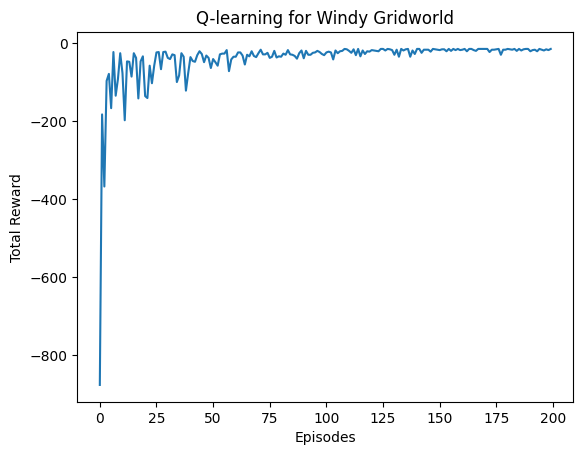

In [13]:
# Plotting learning curve
plt.plot(E_Gt)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld")
plt.show()

In [14]:
# Print last 10 values
print(E_Gt[-10:])

[-21, -18, -17, -21, -15, -17, -19, -16, -18, -15]


We can see that the total reward converges to around -15. This is 15 moves.

It takes about 100 episodes to get to converge to this optimal route policy in a steady mannor.

Lets take a look at the optimal path

In [15]:
max_reward_index = E_Gt.index(max(E_Gt))  # Get index of episode with max reward
print(max_reward_index)
optimal_path = paths[max_reward_index]  # Path corresponding to max reward


108


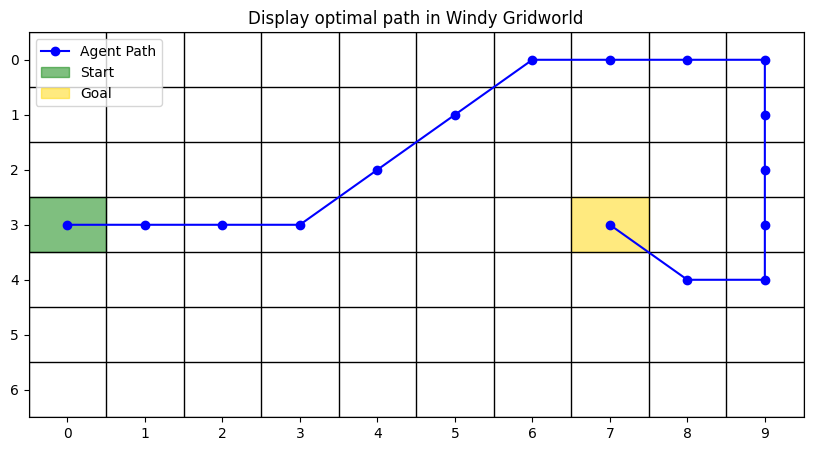

In [16]:
# Function to plot the path correctly
def plot_path(grid_size, path, title="Final Agent Path in Windy Gridworld"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw grid
    for i in range(grid_size[0] + 1):
        ax.plot([-0.5, grid_size[1] - 0.5], [i - 0.5, i - 0.5], "k", lw=1)
    for j in range(grid_size[1] + 1):
        ax.plot([j - 0.5, j - 0.5], [-0.5, grid_size[0] - 0.5], "k", lw=1)

    # Plot the path ensuring it starts at START and ends at GOAL
    path_x, path_y = zip(*path)
    ax.plot(path_y, path_x, marker="o", color="blue", markersize=6, label="Agent Path", linestyle="-")

    # Mark start and goal
    ax.add_patch(plt.Rectangle((start[1] - 0.5, start[0] - 0.5), 1, 1, color="green", alpha=0.5, label="Start"))
    ax.add_patch(plt.Rectangle((goal[1] - 0.5, goal[0] - 0.5), 1, 1, color="gold", alpha=0.5, label="Goal"))

    # Adjust plot limits
    ax.set_xlim(-0.5, grid_size[1] - 0.5)
    ax.set_ylim(grid_size[0] - 0.5, -0.5)  # Invert y-axis for correct display
    ax.set_xticks(range(grid_size[1]))
    ax.set_yticks(range(grid_size[0]))
    ax.set_xticklabels(range(grid_size[1]))
    ax.set_yticklabels(range(grid_size[0]))
    ax.legend()
    ax.set_title(title)

    plt.show()

# Plot path for the last episode
plot_path((rows, cols), optimal_path, "Display optimal path in Windy Gridworld")

We can see the 15 optimal steps taken to get to the Goal.

**Lets try this with Sarsa**

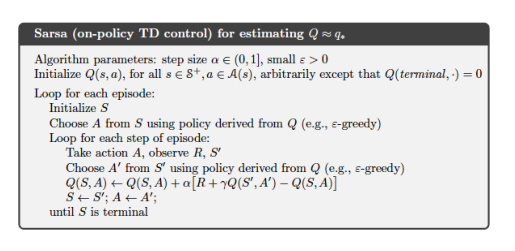

In [17]:
# Load the image
image_path2 = "sarsa.png"  # Replace with your image path
image2 = Image.open(image_path2)

# Display the image
plt.imshow(image2)
plt.axis("off")  # Hide axis labels
plt.show()

In [18]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.1   # Learning rate
gamma = 0.   # reward difference decay rate

In [19]:
E_GtS = []  # Store total rewards per episode
pathsS = []  # Store routes

# Q table creation - Set all values to zero initially
QtableS = {}
for row in range(rows):
    for col in range(cols):
        QtableS[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    At = choose_At(St)  # Choose first action (on-policy)
    Gt = 0
    path = [St]  # Track agent's path, initialize at start point

    while St != goal:
        St1, Rt = take_At(St, At)  # Take step, observe new state and reward
        At1 = choose_At(St1)  # Choose A_{t+1} using epsilon-greedy

        # SARSA update equation
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][At1] - Qtable[St][At])

        # Update for next iteration
        St, At = St1, At1
        Gt += Rt
        path.append(St)  # Append new state

    E_GtS.append(Gt)  # Store total episode reward
    pathsS.append(path)  # Store path for visualization



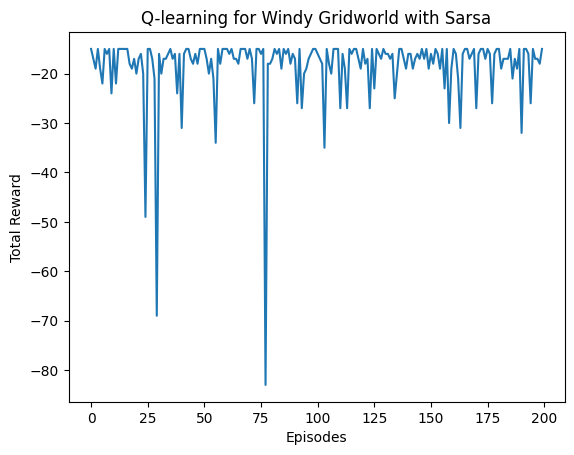

In [20]:
# Plotting learning curve
plt.plot(E_GtS)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld with Sarsa")
plt.show()

This is extremely unstable.

Sarsa is more conservative than Q learning. Q learning takes risks by asusming the best possible action.

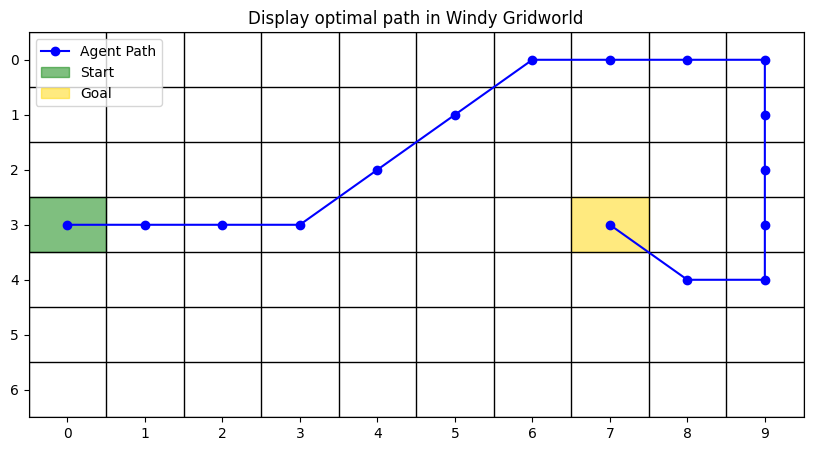

In [21]:
max_reward_indexS = E_GtS.index(max(E_GtS))  # Get index of episode with max reward

optimal_pathS = paths[max_reward_index]  # Path corresponding to max reward
# Plot path for the last episode
plot_path((rows, cols), optimal_pathS, "Display optimal path in Windy Gridworld")

Sarsa gets there quicker but is not stable

## Reflection

Upon my peers comments I found I had been displaying the final path which is not always the optimal one. This was updated.

#### Task 2

***CS5004 DQN Lunar landing Classic Control AY 24/25***


In this task I will look at classic control for lunar landing

This project requires Python 3.10 or above:

In [ ]:
import sys
assert sys.version_info >= (3, 10)

from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.animation
import matplotlib.pyplot as plt

In [ ]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [ ]:
if "google.colab" in sys.modules or "kaggle_secrets" in sys.modules:
    %pip install -q -U gymnasium swig
    %pip install -q -U gymnasium[classic_control,box2d,atari]

import gymnasium as gym

And TensorFlow ≥ 2.8:

Define the default font sizes for plots.

In [ ]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "rl"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Import lunar lander

In [ ]:
import gymnasium as gym

# Create the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")

The LunarLander-v3 environment consists of a spacecraft that must land safely on a designated landing pad. The agent controls the lander by firing thrusters to adjust its position, velocity, and angle. The objective is to land the spacecraft smoothly while minimizing fuel usage and avoiding crashes.

Each observation is a 1D NumPy array composed of 8 floats:

X Position → Horizontal position of the lander.
Y Position → Vertical position of the lander.
X Velocity → Speed of the lander in the horizontal direction.
Y Velocity → Speed of the lander in the vertical direction.
Angle → Orientation of the lander (0 = perfectly upright).
Angular Velocity → How fast the lander is rotating.
Left Leg Contact → 1 if the left leg touches the ground, else 0.
Right Leg Contact → 1 if the right leg touches the ground, else 0.
There are four possible actions:

0 → Do nothing (no thrust).
1 → Fire left thruster (push right).
2 → Fire main thruster (push up).
3 → Fire right thruster (push left).
The agent must control the thrusters to land safely on the landing pad while minimizing fuel consumption and avoiding crashes. The environment provides rewards for smooth landings and penalties for crashes or excessive fuel usage.

From an RL point of view:

The agent is the spaceship.

The environment is the lunar surface.

The state includes position, velocity, and angle.

The actions include firing left, right, or no thrusters.

The reward is based on how well the agent lands.

The lunar lander has a lot of cases for reward. this will make it easier to train. Sparse reward problems like the mountain car can require an extortionate amount of training and stability tuning in order to achieve good results.

In [ ]:
spec = gym.spec("LunarLander-v3")
print(spec)

In [ ]:
# Reset environment and ensure reproducibility
obs, info = env.reset(seed=42)

# Print initial state
print("Observation:", obs)
print("Info:", info)


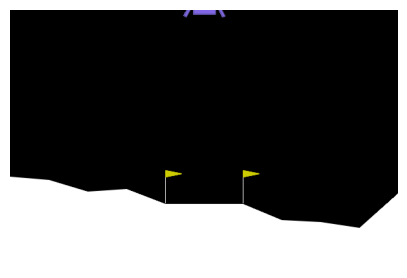

In [ ]:
# extra code – creates a little function to render and plot an environment

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

We are tryign to land within the flags

In [ ]:
env.action_space

action = 1  # accelerate right
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.00449829,  1.4247646 ,  0.22032492,  0.294843  , -0.00285054,
       -0.00391279,  0.        ,  0.        ], dtype=float32)

In [ ]:
if done or truncated:
    obs, info = env.reset()

# Deep Q-Network

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

input_shape = [8]  # LunarLander-v2 has 8 state variables
n_outputs = 4  # == env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="elu", input_shape=input_shape, kernel_initializer="he_normal"),
    tf.keras.layers.Dense(32, activation="elu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(n_outputs)
])

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN

In [ ]:
#  Create the Target Model (Copy of Main Model)
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())  # Copy initial weights


In [ ]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=2000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

Now we can create a function that will use the DQN to play one step, and record its experience in the replay buffer:

In [ ]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

Lastly, let's create a function that will sample some experiences from the replay buffer and perform a training step:

In [ ]:
import numpy as np

In [ ]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [ ]:
batch_size = 64
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-3)
loss_fn = tf.keras.losses.mean_squared_error

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    #next_Q_values = model.predict(next_states, verbose=0)
    next_Q_values = target_model.predict(next_states, verbose=0) # Double DQN
    max_next_Q_values = next_Q_values.max(axis=1)
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    runs = 1.0 - dones  # No need for truncateds
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [ ]:
def is_landed(state):
    return state[6] == 1 and state[7] == 1  # Both legs touching

And now, let's train the model!

In [ ]:
q_values_log = []
rewards = []

for episode in range(300):
    obs, info = env.reset()
    total_reward=0
    epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / 1000)
    # epsilon = 0.9
    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards
        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step(batch_size)

    # Update Target Network every 5 episodes
    if episode % 50 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 44, Steps: 62, Reward: 16.223275924706684, eps: 0.957
 New High Score: 16.22
Episode: 238, Steps: 92, Reward: 20.26442804613133, eps: 0.763
 New High Score: 20.26
Episode: 264, Steps: 142, Reward: 23.320048716329282, eps: 0.737
 New High Score: 23.32
Episode: 273, Steps: 81, Reward: 28.813742871656473, eps: 0.728
 New High Score: 28.81
Episode: 300, Steps: 146, Reward: -352.9427981223861, eps: 0.701

Epsilon decides how much exploration versus exploitation

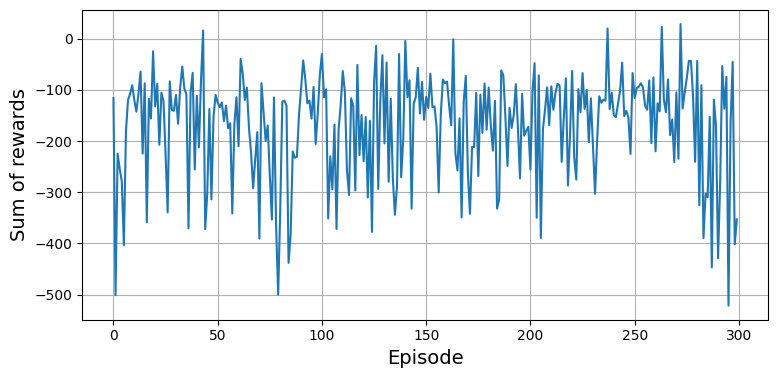

In [ ]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_ll_rewards_plot")
plt.show()

The model seems to get worse which suggests algorithm has some issues. It might be that it needs more time. It is not very stable at all.